# GPT-4 Vision API

GPT-4, 또는 Vision을 포함한 GPT-4V 또는 API라고도 알려져 있는 이 모델은 이미지를 처리하고 이미지에 관한 질문에 답할 수 있는 기능을 갖추고 있습니다. 역사적으로, 언어 모델 시스템은 주로 텍스트만을 사용하는 단일 입력 형식에 제한되어 왔습니다. 이러한 제한 때문에 GPT-4와 같은 모델의 활용 범위가 많은 사용 사례에서 제한되었습니다.

비전 기능을 탑재한 GPT-4는 현재 개발자들이 GPT-4에 접근할 수 있는 Chat Completions API를 통해 모델과 이미지 입력 모두를 지원하는 형태로 업데이트 되었습니다. 반면, Assistants API는 현재 이미지 입력을 지원하지 않습니다.

다음과 같은 사항들을 유념해야 합니다:

- 비전이 탑재된 GPT-4 Turbo는 대화 중 자동으로 삽입되는 시스템 메시지로 인해 GPT-4 Turbo와는 약간 다르게 작동할 수 있습니다.
- 비전이 있는 GPT-4 Turbo는 텍스트 처리 기능에서 GPT-4 Turbo 미리보기 모델과 동일하게 작동하지만, 여기에 비전 기능이 추가되었습니다.
- 비전 기능은 이 모델이 가진 다양한 기능 중 하나일 뿐입니다.

In [2]:
from openai import OpenAI
from IPython.display import Image #이미지를 보기위한 import

client = OpenAI()

## Basic Usage

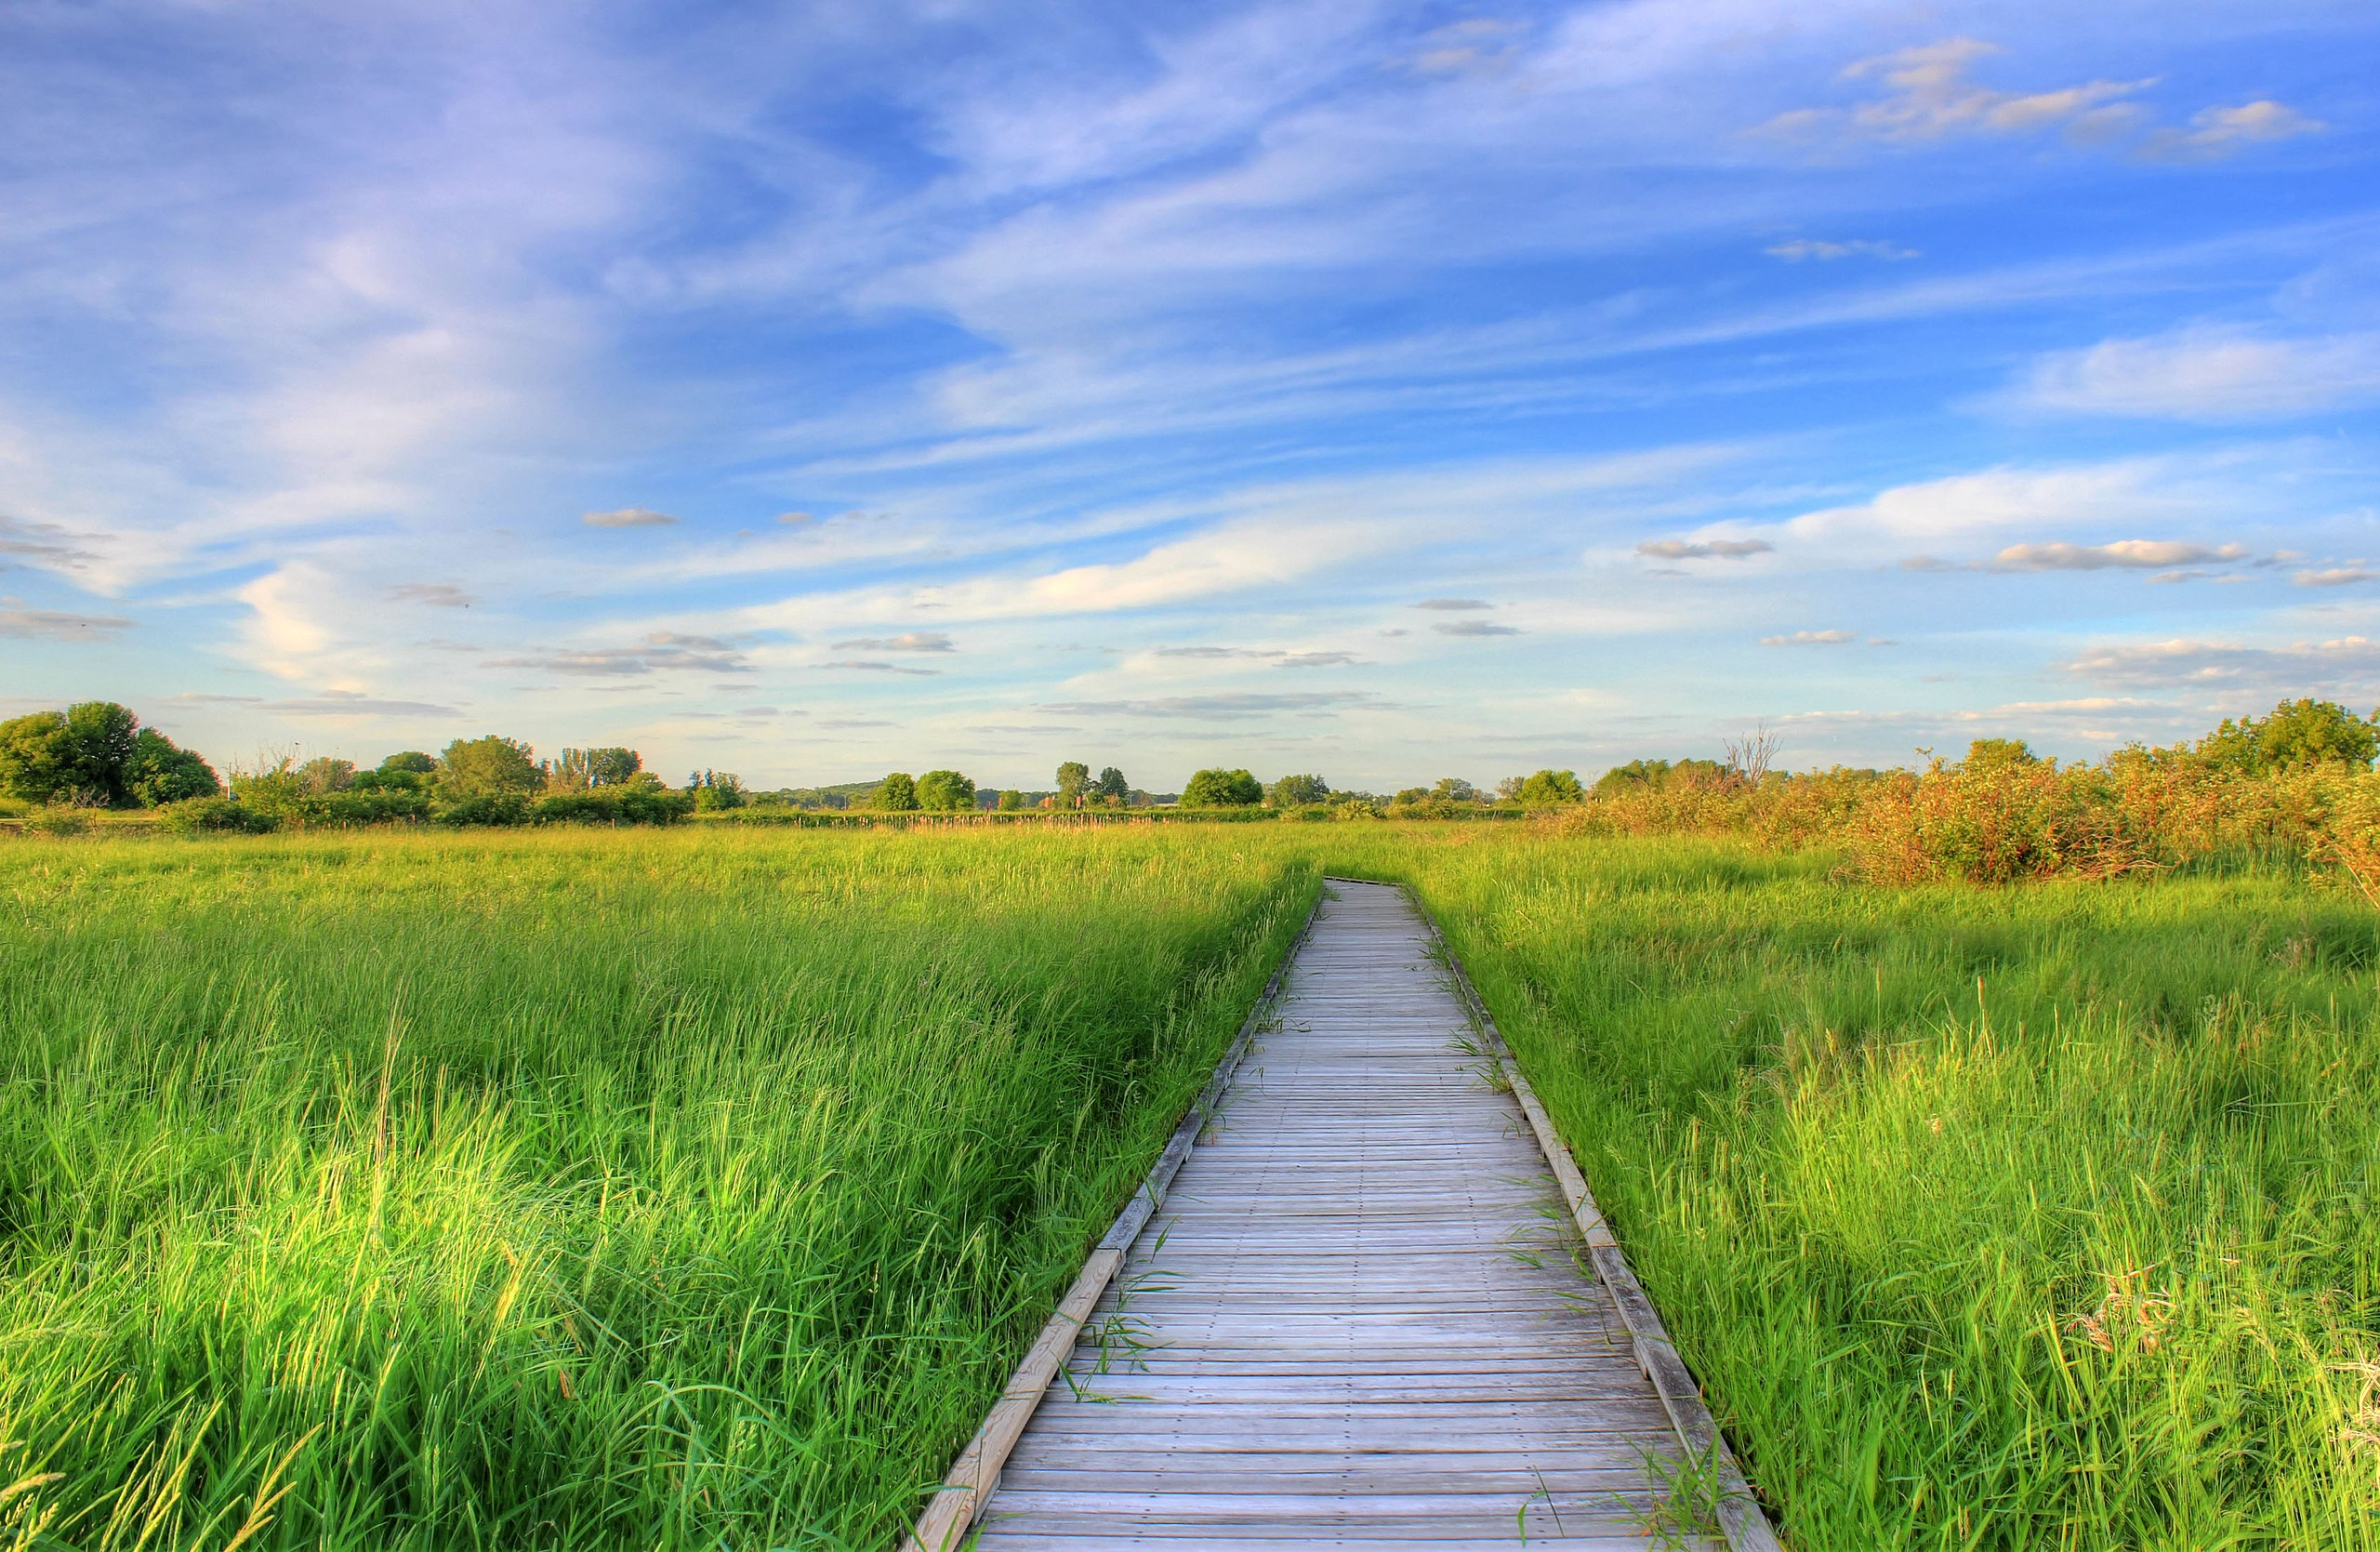

In [3]:
Image("https://upload.wikimedia.org/wikipedia/commons/thumb/d/dd/Gfp-wisconsin-madison-the-nature-boardwalk.jpg/2560px-Gfp-wisconsin-madison-the-nature-boardwalk.jpg", width=480)

In [5]:
response = client.chat.completions.create(
  model="gpt-4o-mini",
  messages=[
    {
      "role": "user",
      "content": [
        {"type": "text", "text": "이 이미지 설명해줘"}, #"type" 으로 리스트 형식으로 content를 만드는 것이 이전과 다름.
        {
          "type": "image_url",
          "image_url": {
            "url": "https://upload.wikimedia.org/wikipedia/commons/thumb/d/dd/Gfp-wisconsin-madison-the-nature-boardwalk.jpg/2560px-Gfp-wisconsin-madison-the-nature-boardwalk.jpg",
          },
        },
      ],
    }
  ],
  max_tokens=300,
)

In [6]:
print(response.choices[0].message.content)

이 이미지는 넓은 초원이 펼쳐진 풍경을 보여줍니다. 사진의 중앙에는 목재로 만들어진 길이 있으며, 이 길은 초원을 지나고 있습니다. 또한 하늘은 푸르고, 구름이 드리워져 있어 평화로운 느낌을 줍니다. 주변에는 푸른 나무와 식물들이 있어 자연의 아름다움이 잘 드러납니다. 전반적으로 고요하고 여유로운 분위기를 느낄 수 있는 장면입니다.


## Local Image 사용하기

In [10]:
image_path = "./sample_img.jpg"

In [11]:
image_path = "./Midjourny_img.png"

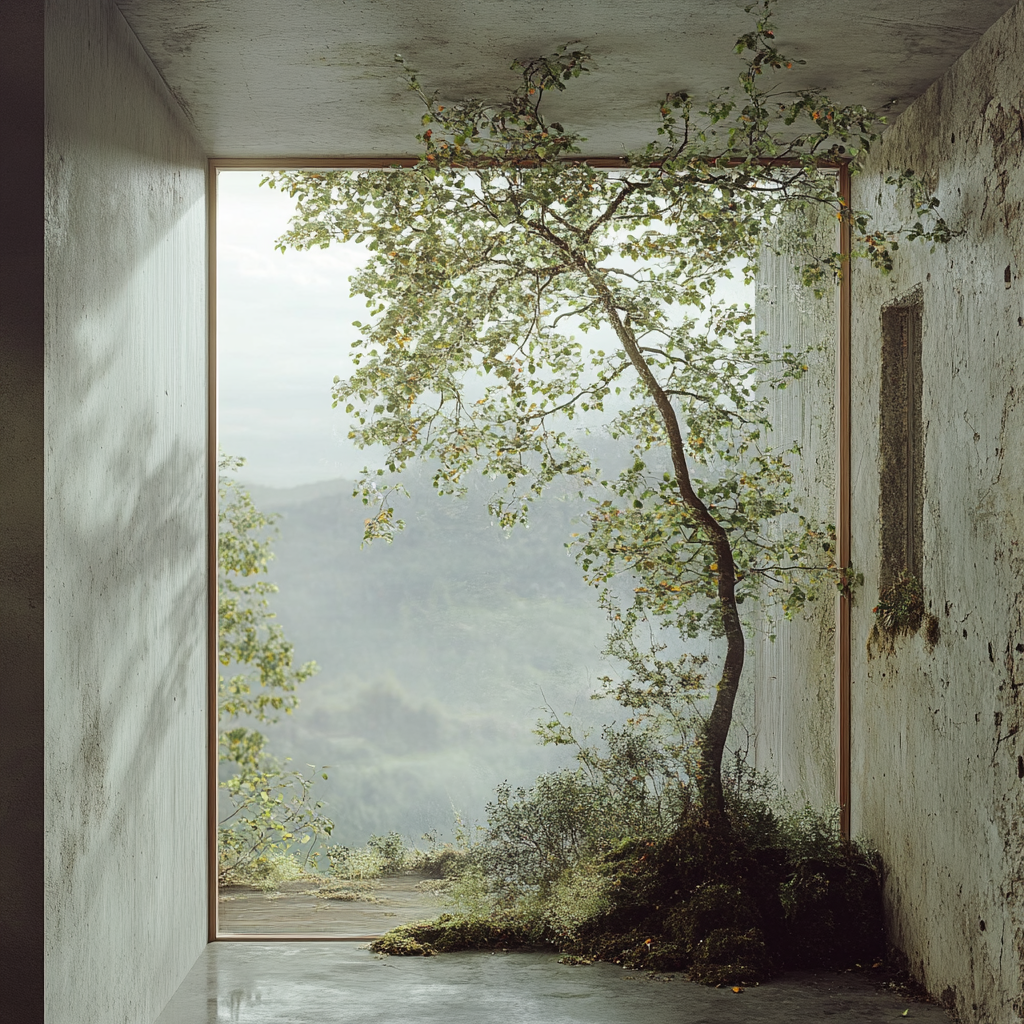

In [12]:
Image(image_path, width=480)

In [14]:
import base64 #base64로 인코딩하여 업로드

In [15]:
def encode_image(image_path):
  with open(image_path, "rb") as image_file:
    return base64.b64encode(image_file.read()).decode('utf-8')

In [16]:
base64_image = encode_image(image_path)

In [17]:
response = client.chat.completions.create(
  model="gpt-4o-mini",
  messages=[
    {
      "role": "user",
      "content": [
        {"type": "text", "text": "이 이미지를 설명해줘"},
        {
          "type": "image_url",
          "image_url": {
            "url": f"data:image/jpeg;base64,{base64_image}",
          },
        },
      ],
    }
  ],
  max_tokens=300,
)

In [18]:
print(response.choices[0].message.content)

이 이미지는 내부 공간과 자연 환경이 조화롭게 연결된 장면을 보여줍니다. 한쪽에는 나무가 자생하고 있으며, 그 앞에는 큰 창문이 있어 외부의 경치가 보입니다. 외부에는 안개 낀 산과 푸른 경치가 펼쳐져 있어 평화롭고 고요한 느낌을 줍니다. 실내는 거친 느낌의 벽과 매끈한 바닥으로 구성되어 있으며, 전체적으로 자연과 인공 구조물이 어우러진 독특한 분위기를 연출합니다.


## 여러장의 이미지

In [19]:
img_1_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/d/dd/Gfp-wisconsin-madison-the-nature-boardwalk.jpg/2560px-Gfp-wisconsin-madison-the-nature-boardwalk.jpg"

In [20]:
img_2_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/d/dd/Gfp-wisconsin-madison-the-nature-boardwalk.jpg/2560px-Gfp-wisconsin-madison-the-nature-boardwalk.jpg"

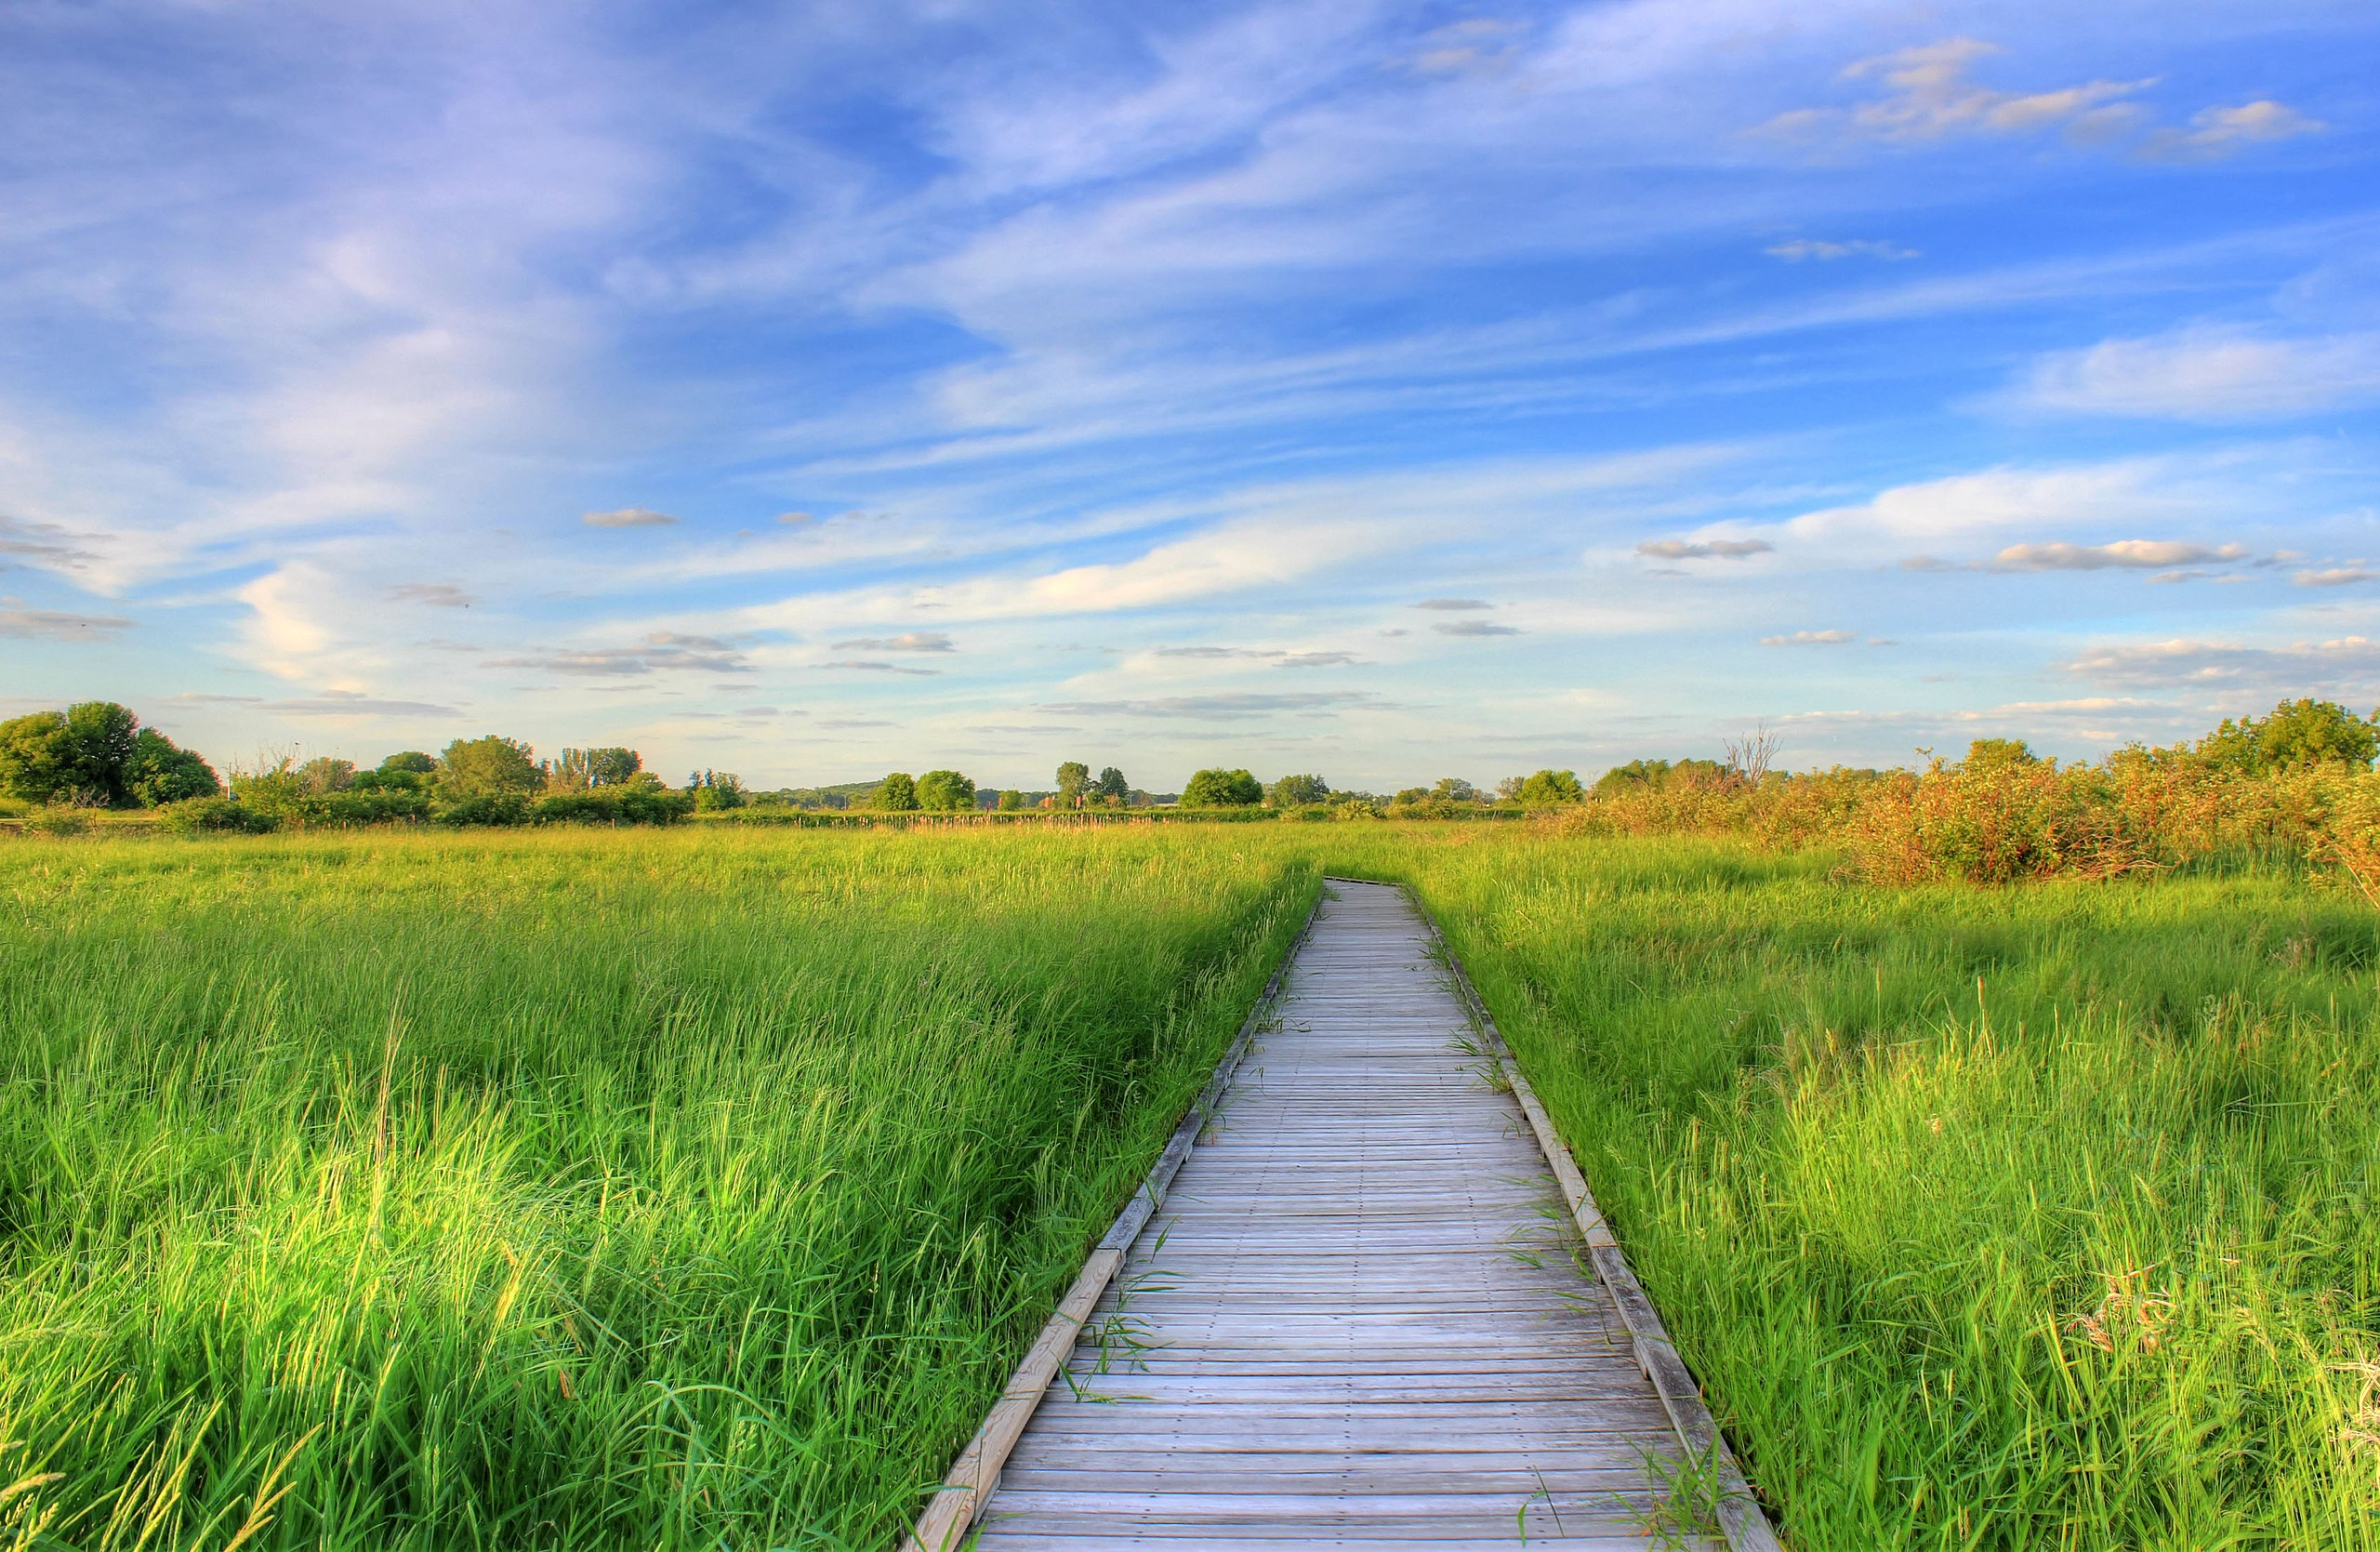

In [21]:
Image(img_1_url, width=480)

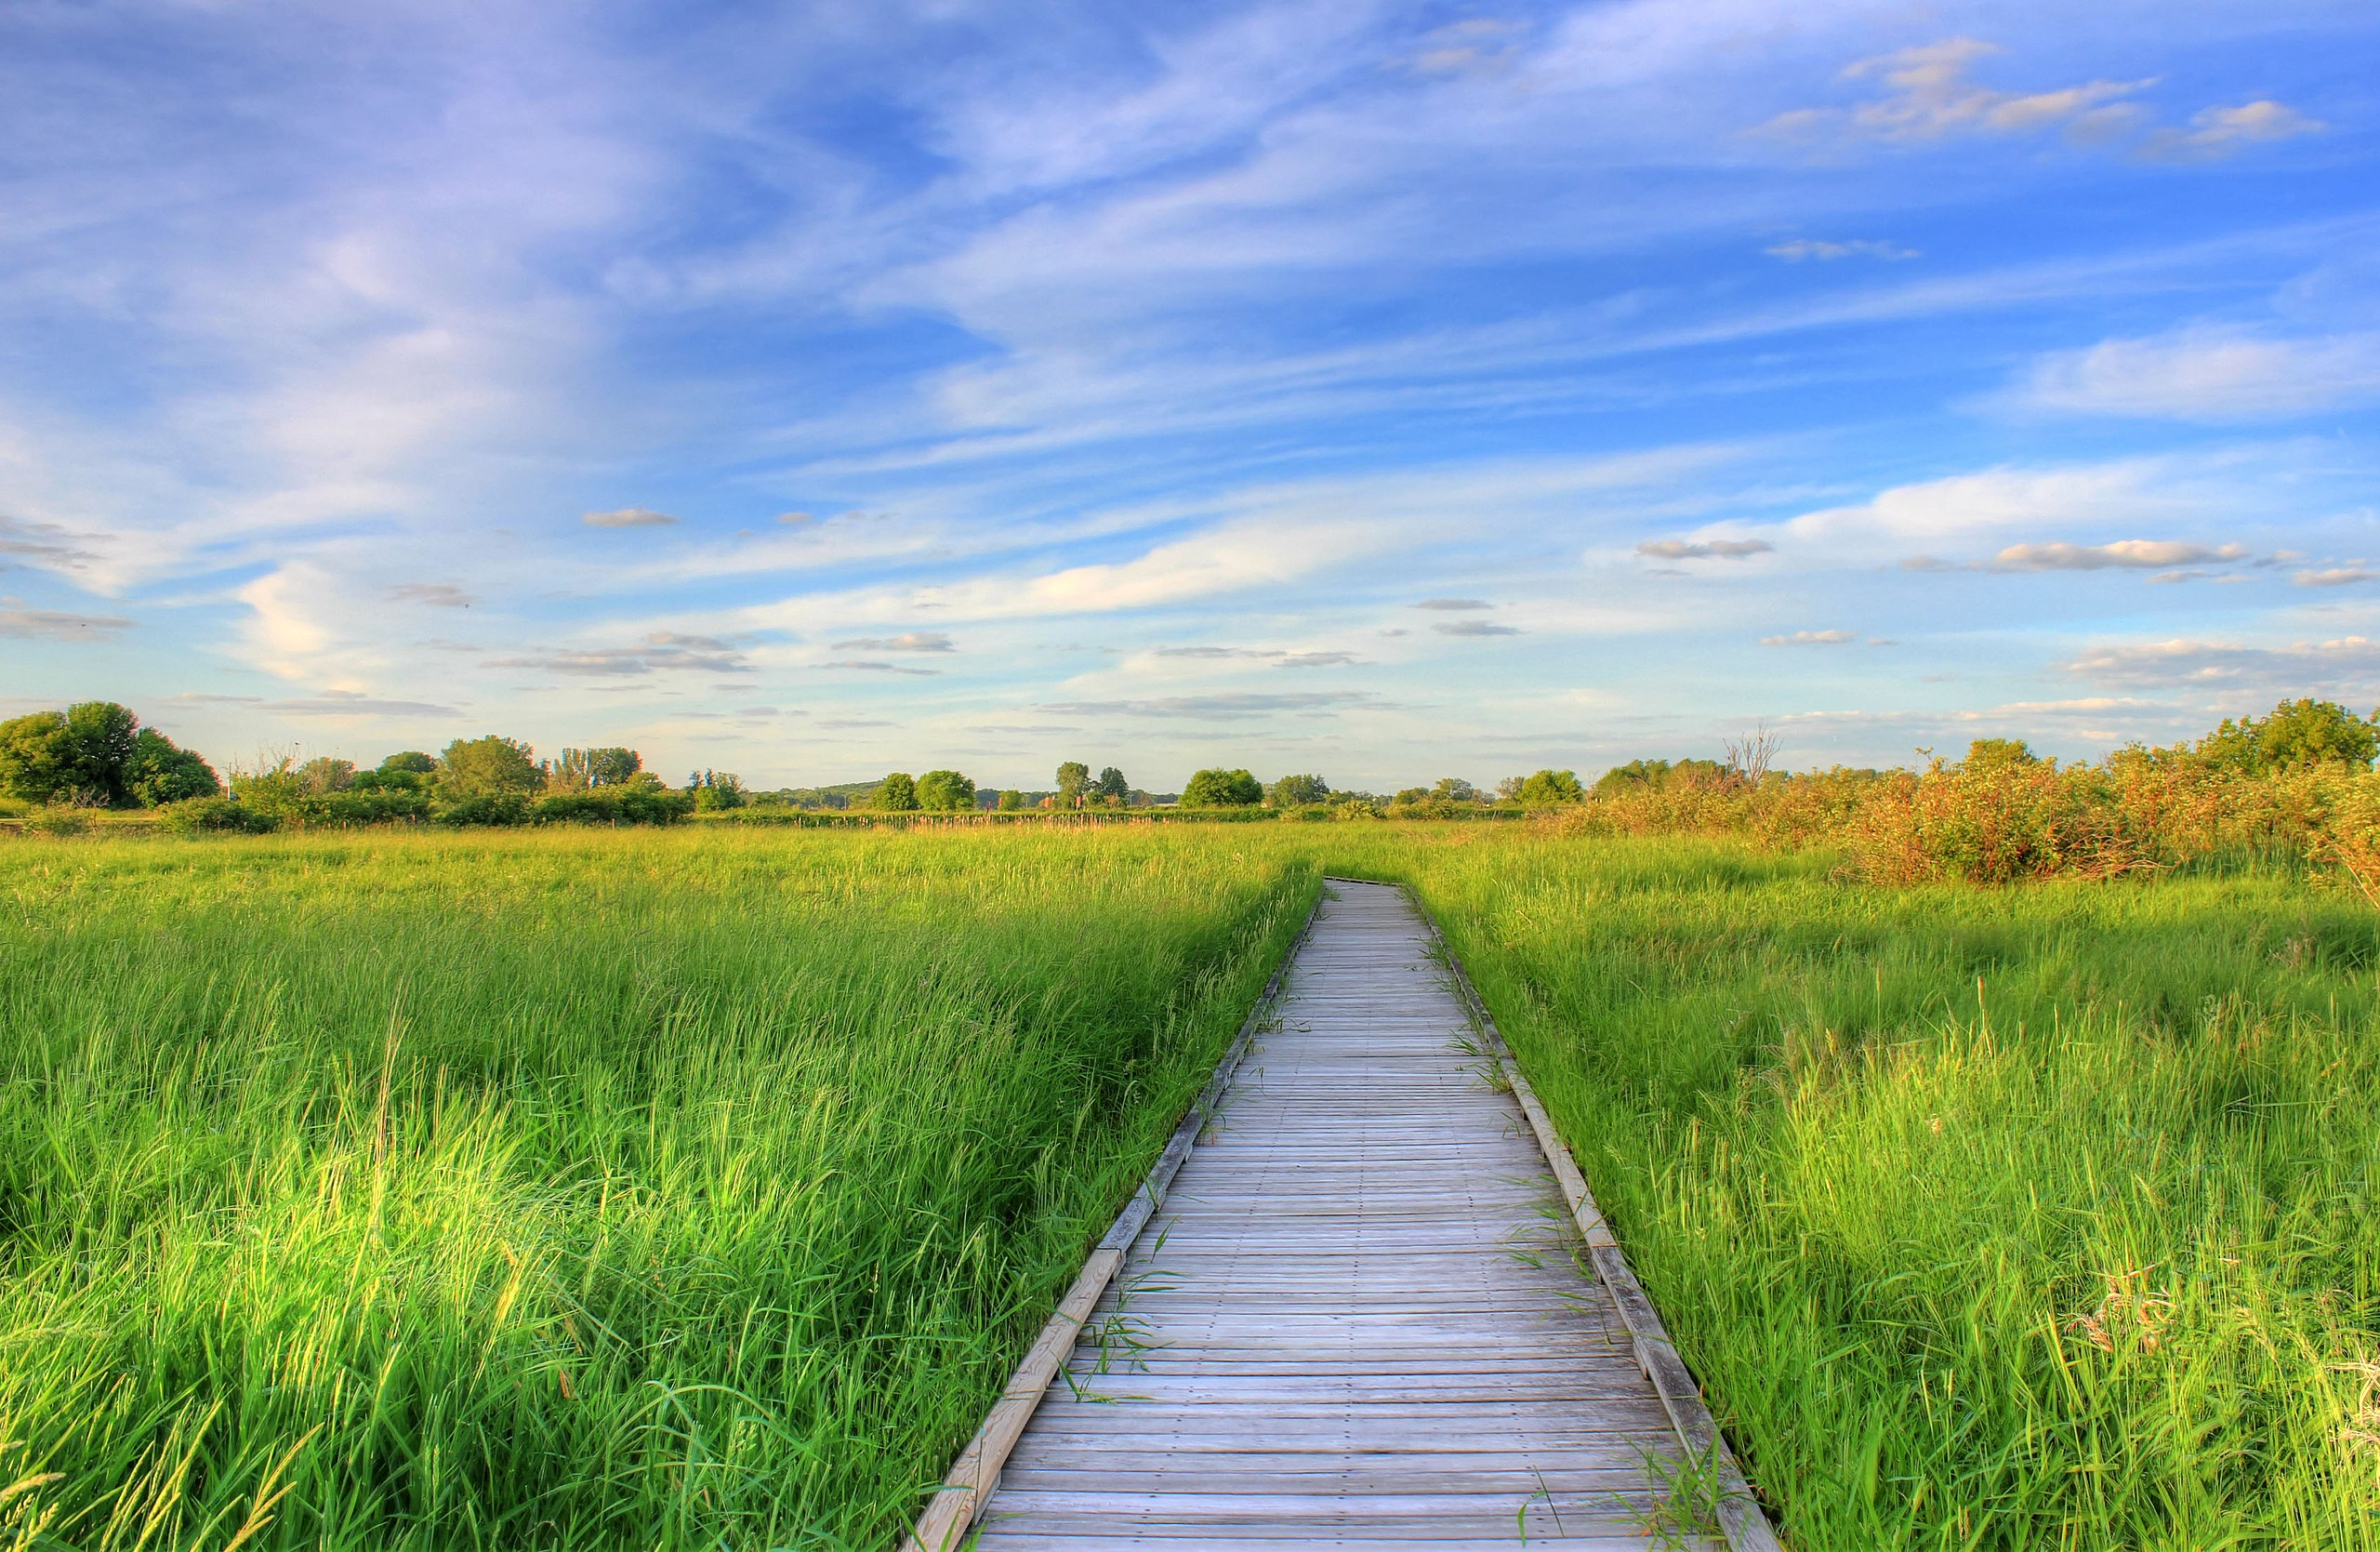

In [22]:
Image(img_2_url, width=480)

In [23]:
response = client.chat.completions.create(
  model="gpt-4o-mini",
  messages=[
    {
      "role": "user",
      "content": [
        {
          "type": "text",
          "text": "이 이미지에는 무엇이 있나요? 이 이미지들 사이에 차이가 있나요?",
        },
        {
          "type": "image_url",
          "image_url": {
            "url": img_1_url,
          },
        },
        {
          "type": "image_url",
          "image_url": {
            "url": img_2_url,
          },
        },
      ],
    }
  ],
  max_tokens=300,
)

In [24]:
print(response.choices[0].message.content)

두 이미지는 동일한 장면을 보여주고 있는 것 같습니다. 풍경 속에 풀이 무성한 지역과 나무들이 보이며, 중앙에는 나무로 만들어진 산책로가 있습니다. 하늘은 맑고 구름이 조금 있는 상태입니다. 차이점이 없다면 어떤 세부 사항이나 색의 변화는 없으며, 같은 이미지를 두 번 보여준 것일 수 있습니다.


## 이미지 이해 해상도 조절
세부 사항 파라미터를 조절함으로써, 사용자는 모델이 이미지를 처리하고 텍스트로 이해하는 방식을 제어할 수 있습니다. 이 파라미터에는 낮음(low), 높음(high), 자동(auto)의 세 가지 옵션이 있습니다. 기본적으로 모델은 자동 설정을 사용하며, 입력된 이미지의 크기를 바탕으로 낮은 설정 또는 높은 설정을 결정합니다.

- `low`은 “고해상도” 모델을 비활성화합니다. 모델은 512px x 512px 해상도의 이미지를 받아서 65 토큰의 예산으로 이미지를 표현합니다. 이는 고해상도의 세부 사항이 필요하지 않은 사용 사례에 더 빠른 응답을 제공하고, 입력 토큰을 적게 소비하게 합니다.
- `high`은 “고해상도” 모드를 활성화합니다. 이 모드는 먼저 모델에게 낮은 해상도 이미지를 보여주고, 입력 이미지 크기에 기반하여 512px 정사각형의 세부적인 크롭을 생성합니다. 각 세부 크롭은 토큰 예산의 두 배인 65토큰(총 129 토큰)을 사용합니다.

In [25]:
response = client.chat.completions.create(
  model="gpt-4o-mini",
  messages=[
    {
      "role": "user",
      "content": [
        {"type": "text", "text": "이 이미지 설명해줘"},
        {
          "type": "image_url",
          "image_url": {
            "url": "https://upload.wikimedia.org/wikipedia/commons/thumb/d/dd/Gfp-wisconsin-madison-the-nature-boardwalk.jpg/2560px-Gfp-wisconsin-madison-the-nature-boardwalk.jpg",
            "detail": "high"
          },
        },
      ],
    }
  ],
  max_tokens=300,
)

In [26]:
print(response.choices[0].message.content)

이 이미지는 넓은 초원이 펼쳐진 풍경을 보여줍니다. 중앙에는 나무로 만들어진 산책로가 이어져 있으며, 길 양 옆으로는 푸른 풀밭과 작은 나무들이 있습니다. 하늘은 푸르고, 구름이 떠 있어 태양의 빛이 비추고 있습니다. 평화롭고 자연적인 분위기를 느낄 수 있습니다.
